In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the classic Titanic dataset (built into seaborn)
df = sns.load_dataset('titanic')

In [5]:
print("=" * 50)
print("DATA OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nBasic Statistics:")
print(df.describe())

DATA OVERVIEW
Shape: (891, 15)

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Data Types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            

# Visualisation


✅ EDA plots saved to 'eda_plots.png'


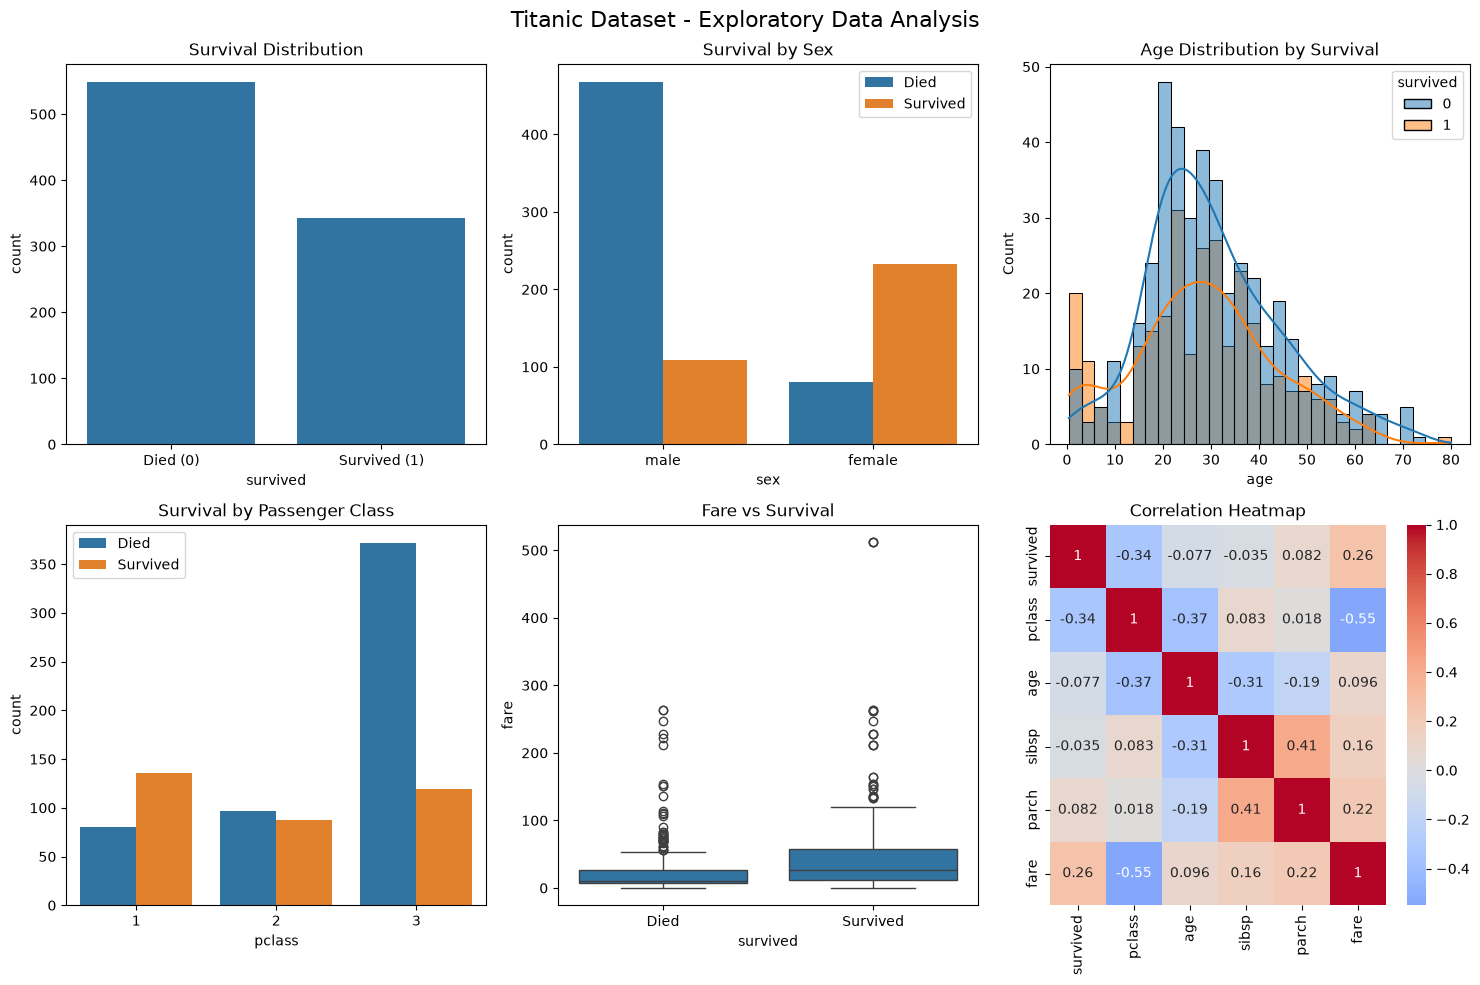

In [6]:
# ---- VISUALIZATIONS ----
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Titanic Dataset - Exploratory Data Analysis', fontsize=16)

# 1. Survival distribution
sns.countplot(data=df, x='survived', ax=axes[0,0])
axes[0,0].set_title('Survival Distribution')
axes[0,0].set_xticklabels(['Died (0)', 'Survived (1)'])

# 2. Survival by Sex
sns.countplot(data=df, x='sex', hue='survived', ax=axes[0,1])
axes[0,1].set_title('Survival by Sex')
axes[0,1].legend(['Died', 'Survived'])

# 3. Age distribution
sns.histplot(data=df, x='age', hue='survived', bins=30, kde=True, ax=axes[0,2])
axes[0,2].set_title('Age Distribution by Survival')

# 4. Survival by Class
sns.countplot(data=df, x='pclass', hue='survived', ax=axes[1,0])
axes[1,0].set_title('Survival by Passenger Class')
axes[1,0].legend(['Died', 'Survived'])

# 5. Fare distribution
sns.boxplot(data=df, x='survived', y='fare', ax=axes[1,1])
axes[1,1].set_title('Fare vs Survival')
axes[1,1].set_xticklabels(['Died', 'Survived'])

# 6. Correlation heatmap (numeric only)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
print("\n✅ EDA plots saved to 'eda_plots.png'")
plt.show()

# # ---- KEY INSIGHTS ----

In [7]:
print("\n" + "=" * 50)
print("KEY INSIGHTS")
print("=" * 50)
print(f"• Survival rate: {df['survived'].mean():.1%}")
print(f"• Female survival rate: {df[df['sex']=='female']['survived'].mean():.1%}")
print(f"• Male survival rate: {df[df['sex']=='male']['survived'].mean():.1%}")
print(f"• 1st class survival rate: {df[df['pclass']==1]['survived'].mean():.1%}")
print(f"• 3rd class survival rate: {df[df['pclass']==3]['survived'].mean():.1%}")


KEY INSIGHTS
• Survival rate: 38.4%
• Female survival rate: 74.2%
• Male survival rate: 18.9%
• 1st class survival rate: 63.0%
• 3rd class survival rate: 24.2%
